<a href="https://colab.research.google.com/github/be0wulf2001/Machine-Learning-Lab/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Load dataset

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Feature Names:", data.feature_names)

Dataset Shape: (569, 30)
Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [ ]:
# Split and standardize

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Sigmoid function

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [ ]:
# Logistic Regression training

def logistic_regression_train(X, y, learning_rate=0.05, epochs=3000):

    weights = np.zeros(X.shape[1])
    bias = 0.0
    n = len(y)

    for epoch in range(epochs):

        linear_model = np.dot(X, weights) + bias
        predictions = sigmoid(linear_model)

        dw = np.dot(X.T, (predictions - y)) / n
        db = np.mean(predictions - y)

        weights -= learning_rate * dw
        bias -= learning_rate * db

    return weights, bias

In [ ]:
# Logistic Regression prediction

def logistic_regression_predict(X, weights, bias):

    probabilities = sigmoid(np.dot(X, weights) + bias)

    return (probabilities >= 0.5).astype(int)

In [ ]:
# Perceptron training

def perceptron_train(X, y, learning_rate=0.01, epochs=100):

    weights = np.zeros(X.shape[1])
    bias = 0.0

    y_modified = np.where(y == 0, -1, 1)

    for epoch in range(epochs):

        errors = 0

        for xi, yi in zip(X, y_modified):

            prediction = np.dot(weights, xi) + bias

            if yi * prediction <= 0:

                weights += learning_rate * yi * xi
                bias += learning_rate * yi

                errors += 1

        if errors == 0:
            break

    return weights, bias

In [ ]:
# Perceptron prediction

def perceptron_predict(X, weights, bias):

    predictions = np.dot(X, weights) + bias

    return (predictions >= 0).astype(int)

In [ ]:
# Train models

logistic_weights, logistic_bias = logistic_regression_train(
    X_train, y_train
)

perceptron_weights, perceptron_bias = perceptron_train(
    X_train, y_train
)

In [ ]:
# Predictions

logistic_predictions = logistic_regression_predict(
    X_test, logistic_weights, logistic_bias
)

perceptron_predictions = perceptron_predict(
    X_test, perceptron_weights, perceptron_bias
)

In [ ]:
# Evaluation function

def evaluate_model(y_true, y_pred, model_name):

    print("\n", model_name)
    print("-" * 35)

    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall:", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1-Score:", round(f1_score(y_true, y_pred, zero_division=0), 4))

In [ ]:
# Evaluate models

evaluate_model(y_test, logistic_predictions, "Logistic Regression")

evaluate_model(y_test, perceptron_predictions, "Perceptron")


 Logistic Regression
-----------------------------------
Accuracy: 0.9649
Precision: 0.9857
Recall: 0.9583
F1-Score: 0.9718

 Perceptron
-----------------------------------
Accuracy: 0.9649
Precision: 0.9857
Recall: 0.9583
F1-Score: 0.9718


In [ ]:
# Select two features

feature_indices = [0, 1]

X_2d = data.data[:, feature_indices]
y_2d = data.target

print(data.feature_names[feature_indices])

['mean radius' 'mean texture']


In [ ]:
# Split and standardize 2D data

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

scaler_2d = StandardScaler()

X_train_2d = scaler_2d.fit_transform(X_train_2d)
X_test_2d = scaler_2d.transform(X_test_2d)

In [ ]:
# Train 2D models

lr_w_2d, lr_b_2d = logistic_regression_train(
    X_train_2d, y_train_2d
)

p_w_2d, p_b_2d = perceptron_train(
    X_train_2d, y_train_2d
)

In [ ]:
# Create mesh grid

x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1

y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

In [ ]:
# Predict grid values

lr_grid_predictions = logistic_regression_predict(
    grid, lr_w_2d, lr_b_2d
).reshape(xx.shape)

p_grid_predictions = perceptron_predict(
    grid, p_w_2d, p_b_2d
).reshape(xx.shape)

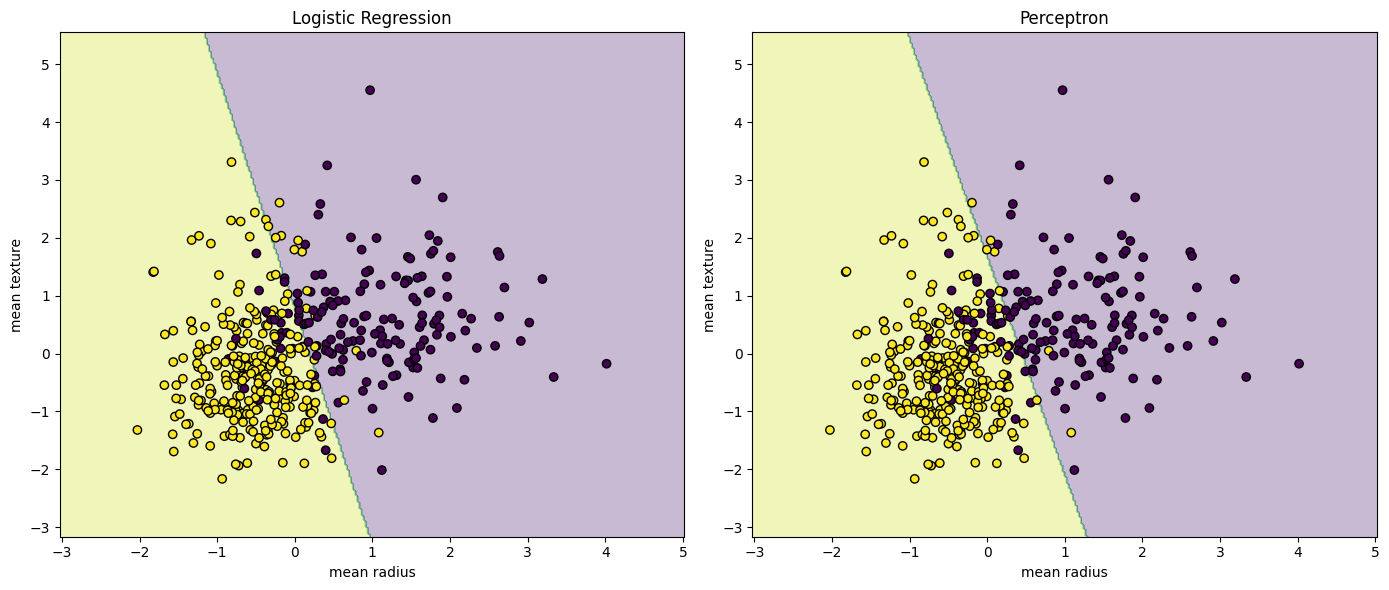

In [ ]:
# Plot decision boundaries

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].contourf(xx, yy, lr_grid_predictions, alpha=0.3)

axes[0].scatter(
    X_train_2d[:, 0], X_train_2d[:, 1],
    c=y_train_2d, edgecolors="black"
)

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel(data.feature_names[0])
axes[0].set_ylabel(data.feature_names[1])

axes[1].contourf(xx, yy, p_grid_predictions, alpha=0.3)

axes[1].scatter(
    X_train_2d[:, 0], X_train_2d[:, 1],
    c=y_train_2d, edgecolors="black"
)

axes[1].set_title("Perceptron")
axes[1].set_xlabel(data.feature_names[0])
axes[1].set_ylabel(data.feature_names[1])

plt.tight_layout()
plt.show()